# Charlottesville, Virginia — LVT Policy Analysis

Charlottesville is a small independent city in central Virginia, home to the University of Virginia (UVA). As a Virginia independent city, it is not part of any county and functions as its own county-equivalent for all tax and census purposes.

Virginia is an **assessment-at-market-value** state: all real property must be assessed at 100% of fair market value (Virginia Code § 58.1-3201). There is no common level ratio or equalization factor to apply — assessed values in the city's system are, in principle, full market values.

### Charlottesville 2025 Real Estate Tax

| Metric | Value |
|---|---|
| Tax Rate | $0.98 per $100 assessed value (9.8 mills) |
| Total Taxable Parcels | ~15,137 |
| Total Assessed Value | ~$11.69 billion |
| Total Tax Revenue | ~$114.6 million |

### Data Sources

All parcel data comes from Charlottesville's publicly hosted ArcGIS REST services:
- **OpenData_2 MapServer** (assessment tables, no geometry): `gisweb.charlottesville.org/arcgis/rest/services/OpenData_2/MapServer`
  - Layer 2: All Assessments → `LandValue`, `ImprovementValue`, `TotalValue`
  - Layer 20: Base Parcel Data → `TaxType` (Taxable/Exempt), `StateCode` (use code), `GPIN`, `Zone`
  - Layer 17: Residential Details → `UseCode` (granular residential classification)
  - Layer 19: Commercial Details → `UseCode` (granular commercial classification)
- **OpenData_1 MapServer** (geometry): `gisweb.charlottesville.org/cvgisweb/rest/services/OpenData_1/MapServer`
  - Layer 43: Parcel Boundary (GPIN + polygon geometry)

### Modeling Approach

This notebook models the **full city real estate tax levy** (there is no county/school split — Charlottesville is the taxing authority for all purposes as an independent city). All scenarios are revenue-neutral at the 2025 rate of 9.8 mills applied to total assessed value.

**UVA consideration**: The University of Virginia owns a substantial portion of Charlottesville's land area and is exempt from property taxes as a state institution. These parcels (TaxType = 'Exempt', StateCode starting with '7.') are excluded from the taxable modeling base.


In [1]:
import os
import sys
import time
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from dotenv import load_dotenv
from shapely.geometry import Polygon, MultiPolygon

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "lvt_utils.py").exists():
    REPO_ROOT = REPO_ROOT.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

load_dotenv(REPO_ROOT / ".env")

from census_utils import get_census_data_with_boundaries, match_to_census_blockgroups
from lvt_utils import (
    calculate_category_tax_summary,
    calculate_current_tax,
    model_split_rate_tax,
    print_category_tax_summary,
)
from policy_analysis import (
    analyze_parking_lots,
    analyze_vacant_land,
    print_parking_analysis_summary,
    print_vacant_land_summary,
)
from viz import calculate_block_group_summary

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 200)

In [2]:
# ---- Configuration ----

# 2025 Charlottesville real estate tax rate: $0.98 per $100 = 9.8 mills
CITY_MILLAGE = 9.8

# Charlottesville is an independent city; Census treats it as a county equivalent
# State FIPS 51 (Virginia) + City FIPS 540 = county-equivalent FIPS 51540
CHARLOTTESVILLE_FIPS = "51540"

# ArcGIS REST base URLs
OPENDATA2_URL = "https://gisweb.charlottesville.org/arcgis/rest/services/OpenData_2/MapServer"
OPENDATA1_URL = "https://gisweb.charlottesville.org/cvgisweb/rest/services/OpenData_1/MapServer"

# Layer IDs in OpenData_2 (tables, no geometry)
LAYER_ALL_ASSESSMENTS = 2     # LandValue, ImprovementValue, TotalValue, TaxYear
LAYER_BASE_DATA = 20          # TaxType, StateCode, GPIN, Zone, ParcelNumber
LAYER_RESIDENTIAL = 17        # UseCode (residential detail)
LAYER_COMMERCIAL = 19         # UseCode (commercial detail)

# Layer IDs in OpenData_1 (has geometry)
LAYER_PARCEL_BOUNDARY = 43    # GPIN + polygon geometry
LAYER_PARCEL_DETAILS = 72     # OwnerName, ParcelNumber, GPIN, Assessment, geometry

# Data directories
data_dir = REPO_ROOT / "examples" / "data" / "charlottesville"
data_dir.mkdir(parents=True, exist_ok=True)

# Data scrape flag: 1 = fetch fresh data from GIS, 0 = load from cached parquet
data_scrape = 0

print(f"Data directory:       {data_dir}")
print(f"City millage:         {CITY_MILLAGE} mills")
print(f"Equivalent rate:      ${CITY_MILLAGE/10:.2f} per $100")
print(f"Census FIPS:          {CHARLOTTESVILLE_FIPS}")

Data directory:       /Users/gregmiller/Documents/CLE/cle/LVTShift/examples/data/charlottesville
City millage:         9.8 mills
Equivalent rate:      $0.98 per $100
Census FIPS:          51540


## Step 1: Fetch Assessment Data

The Charlottesville OpenData_2 MapServer hosts several tables (without geometry) that together capture the full parcel tax record:

- **Layer 2 (All Assessments)**: `LandValue`, `ImprovementValue`, `TotalValue` for each `ParcelNumber` by `TaxYear`. Multiple years available; we filter to the most recent.
- **Layer 20 (Base Data)**: `TaxType` (Taxable/Exempt), `StateCode` (Virginia use category), `GPIN` (join key to geometry), `Zone`, `IsActive`.
- **Layer 17 / 19 (Detail tables)**: `UseCode` with granular property use descriptions (Single Family, Apartment, etc.)

The join key is `ParcelNumber` (a string like `"010001000"`) shared across Layer 2 and Layer 20. Geometry is joined via the `GPIN` field from Layer 20 to the parcel boundary layer.

In [3]:
def fetch_arcgis_table(base_url: str, layer_id: int, where: str = "1=1",
                       out_fields: str = "*", order_by: str = "",
                       max_records: int = 100_000) -> pd.DataFrame:
    """Fetch all records from an ArcGIS table layer using offset pagination."""
    query_url = f"{base_url}/{layer_id}/query"

    # Get total count
    count_resp = requests.get(
        query_url,
        params={"f": "json", "where": where, "returnCountOnly": "true"},
        timeout=60,
    )
    count_resp.raise_for_status()
    total = count_resp.json().get("count", 0)
    print(f"  Layer {layer_id}: {total:,} records to fetch")

    all_rows = []
    offset = 0
    chunk = 2000

    while offset < min(total, max_records):
        params = {
            "f": "json",
            "where": where,
            "outFields": out_fields,
            "returnGeometry": "false",
            "resultOffset": offset,
            "resultRecordCount": chunk,
        }
        if order_by:
            params["orderByFields"] = order_by
        resp = requests.get(query_url, params=params, timeout=120)
        resp.raise_for_status()
        data = resp.json()
        features = data.get("features", [])
        if not features:
            break
        for feat in features:
            all_rows.append(feat["attributes"])
        offset += len(features)
        if len(features) < chunk:
            break
        time.sleep(0.15)

    df = pd.DataFrame(all_rows)
    print(f"    → loaded {len(df):,} rows")
    return df


def fetch_arcgis_geometry(base_url: str, layer_id: int, where: str = "1=1",
                          out_fields: str = "*") -> gpd.GeoDataFrame:
    """Fetch all polygon features from an ArcGIS feature layer."""
    query_url = f"{base_url}/{layer_id}/query"

    count_resp = requests.get(
        query_url,
        params={"f": "json", "where": where, "returnCountOnly": "true"},
        timeout=60,
    )
    count_resp.raise_for_status()
    total = count_resp.json().get("count", 0)
    print(f"  Geometry layer {layer_id}: {total:,} features to fetch")

    all_feats = []
    offset = 0
    chunk = 1000

    while offset < total:
        params = {
            "f": "json",
            "where": where,
            "outFields": out_fields,
            "returnGeometry": "true",
            "outSR": "4326",
            "geometryPrecision": 6,
            "resultOffset": offset,
            "resultRecordCount": chunk,
        }
        resp = requests.get(query_url, params=params, timeout=120)
        resp.raise_for_status()
        data = resp.json()
        features = data.get("features", [])
        if not features:
            break
        for feat in features:
            attrs = feat.get("attributes", {}).copy()
            geom_data = feat.get("geometry", {})
            geometry = None
            if geom_data and "rings" in geom_data and geom_data["rings"]:
                rings = geom_data["rings"]
                try:
                    if len(rings) == 1:
                        geometry = Polygon(rings[0])
                    else:
                        exterior = rings[0]
                        holes = [r for r in rings[1:] if len(r) >= 4]
                        geometry = Polygon(exterior, holes)
                except Exception:
                    geometry = Polygon(rings[0]) if rings else None
            attrs["geometry"] = geometry
            all_feats.append(attrs)
        if len(features) < chunk:
            break
        offset += len(features)
        time.sleep(0.2)

    gdf = gpd.GeoDataFrame(all_feats, geometry="geometry", crs="EPSG:4326")
    valid = gdf["geometry"].notna().sum()
    print(f"    → {valid:,} valid geometries of {len(gdf):,} features")
    return gdf

In [4]:
assess_cache = data_dir / "cville_assessments.parquet"
base_cache = data_dir / "cville_base.parquet"
res_cache = data_dir / "cville_residential.parquet"
comm_cache = data_dir / "cville_commercial.parquet"

if data_scrape == 1:
    print("Fetching assessment tables from OpenData_2 MapServer...")

    # All assessments — filter to most recent tax year
    # First, find what years are available
    sample = fetch_arcgis_table(OPENDATA2_URL, LAYER_ALL_ASSESSMENTS,
                                 where="1=1", out_fields="TaxYear",
                                 order_by="TaxYear DESC", max_records=10)
    latest_year = sample["TaxYear"].dropna().iloc[0] if len(sample) > 0 else "2025"
    print(f"  Most recent TaxYear in assessments: {latest_year}")

    assess_raw = fetch_arcgis_table(
        OPENDATA2_URL, LAYER_ALL_ASSESSMENTS,
        where=f"TaxYear='{latest_year}'",
        out_fields="*",
        order_by="RecordID_Int",
    )
    assess_raw.to_parquet(assess_cache, index=False)
    print(f"  Saved assessments → {assess_cache}")

    # Base data — all active parcels
    base_raw = fetch_arcgis_table(
        OPENDATA2_URL, LAYER_BASE_DATA,
        where="IsActive=1",
        out_fields="*",
        order_by="RecordID_Int",
    )
    base_raw.to_parquet(base_cache, index=False)
    print(f"  Saved base data   → {base_cache}")

    # Residential details for UseCode
    res_raw = fetch_arcgis_table(
        OPENDATA2_URL, LAYER_RESIDENTIAL,
        where="1=1",
        out_fields="*",
        order_by="RecordID_Int",
    )
    res_raw.to_parquet(res_cache, index=False)
    print(f"  Saved residential → {res_cache}")

    # Commercial details for UseCode
    comm_raw = fetch_arcgis_table(
        OPENDATA2_URL, LAYER_COMMERCIAL,
        where="1=1",
        out_fields="*",
        order_by="RecordID_Int",
    )
    comm_raw.to_parquet(comm_cache, index=False)
    print(f"  Saved commercial  → {comm_cache}")

else:
    assess_raw = pd.read_parquet(assess_cache)
    base_raw = pd.read_parquet(base_cache)
    res_raw = pd.read_parquet(res_cache)
    comm_raw = pd.read_parquet(comm_cache)
    print(f"Loaded from cache:")
    print(f"  Assessments: {len(assess_raw):,} rows")
    print(f"  Base data:   {len(base_raw):,} rows")
    print(f"  Residential: {len(res_raw):,} rows")
    print(f"  Commercial:  {len(comm_raw):,} rows")

pd.set_option("display.max_columns", None)

print("\nAssessments columns:")
print(assess_raw.columns.tolist())
print("\nBase columns:")
print(base_raw.columns.tolist())
print("\nResidential columns:")
print(res_raw.columns.tolist())
print("\nCommercial columns:")
print(comm_raw.columns.tolist())

print("\nAssessments raw head(5):")
display(assess_raw.head(5))

print("Base raw head(5):")
display(base_raw.head(5))

print("Residential raw head(5):")
display(res_raw.head(5))

print("Commercial raw head(5):")
display(comm_raw.head(5))

Fetching assessment tables from OpenData_2 MapServer...


  Layer 2: 442,952 records to fetch


    → loaded 2,000 rows
  Most recent TaxYear in assessments: 2026


  Layer 2: 16,067 records to fetch


    → loaded 16,067 rows
  Saved assessments → /Users/gregmiller/Documents/CLE/cle/LVTShift/examples/data/charlottesville/cville_assessments.parquet


...

,RecordID_Int,Acreage,GPIN,IsActive,Legal,ParcelNumber,StreetNumber,StreetName,StateCode,TaxDist,TaxType,Unit,Zone
0,1,39.77,1326,1,39.77 ACRES BARRACKS ROAD SHOPPING CENTER,010001000,1117,EMMET ST N,4.0 Commercial & Industrial,,Taxable,,NX-10
1,2,2.14,15071,1,PARCEL W WEST BAR,010001100,1035-67,MILLMONT ST,4.0 Commercial & Industrial,,Taxable,,NX-10
2,3,0.58,1280,1,LOT C-1 WEST BAR,010001200,1159,MILLMONT ST,4.0 Commercial & Industrial,,Taxable,,NX-10
3,4,0.40,1357,1,LOT C-2B WEST BAR,010001300,1135-37,MILLMONT ST,4.0 Commercial & Industrial,,Taxable,,NX-10
4,5,3.28,1366,1,LOT B-1 WEST BAR,010001400,1111,MILLMONT ST,4.0 Commercial & Industrial,,Taxable,,NX-10


Residential raw head(5):


,RecordID_Int,Basement,BasementGarage,Bedrooms,BasementType,ExternalWalls,FinishedBasement,Flooring,Fireplace,FullBathrooms,Grade,HalfBathrooms,Heating,NumberOfStories,ParcelNumber,Roof,SquareFootageFinishedLiving,StreetName,StreetNumber,Style,TotalRooms,Unit,UseCode,YearBuilt
0,1,0,0,4,No Basement,Wood,0,None,0,4,A,0,Forced Air,2.00,010001600,Metal,3672,MASSIE RD,600,2 Story,8,,Multipurpose Bldg (College),1920
1,2,0,,,,,0,,,,,,,,010005000,,,BARRACKS RD,2030,,,,Vacant Land,
2,3,1163,0,6,Walkout Basement,Brick Veneer,1018,Hardwood,2,4,A,1,Hot Water Radiator,2.00,010006000,Arch Shingles,3305,BARRACKS RD,2028,2 Story,10,,Single Family,1940
3,4,1699,0,5,Partial Basement,Brick Veneer,1468,Hardwood,3,4,A -,1,Hot Water Radiator,2.00,010007000,Slate,5474,DAIRY RD,1930,2 Sty Excellent,13,,Single Family,1939
4,5,0,,,,,0,,,,,,,,010008000,,,BARRACKS RD,1924,,,,Vacant Land,


Commercial raw head(5):


,RecordID_Int,GrossArea,NumberOfStories,ParcelNumber,StoryHeight,StreetName,StreetNumber,Unit,UseCode,YearBuilt,BuildingIDNumber
0,1,497658,1.00,010001000,12.0,EMMET ST N,1117,,Comm. Shopping Ctr.,1957.0,249299.0
1,2,497658,1.00,010001000,12.0,EMMET ST N,1117,,Comm. Shopping Ctr.,1957.0,249299.0
2,3,497658,1.00,010001000,12.0,EMMET ST N,1117,,Comm. Shopping Ctr.,1957.0,249299.0
3,4,497658,1.00,010001000,12.0,EMMET ST N,1117,,Comm. Shopping Ctr.,1957.0,249299.0
4,5,497658,1.00,010001000,12.0,EMMET ST N,1117,,Comm. Shopping Ctr.,1957.0,249299.0


In [5]:
geom_cache = data_dir / "cville_geometry.parquet"

if data_scrape == 1:
    print("Fetching parcel geometry from OpenData_1 MapServer (Layer 43 - Parcel Boundary)...")
    try:
        parcel_geom = fetch_arcgis_geometry(
            OPENDATA1_URL, LAYER_PARCEL_BOUNDARY,
            where="1=1",
            out_fields="*",
        )
        parcel_geom.to_parquet(geom_cache, index=False)
        print(f"  Saved geometry → {geom_cache}")
    except Exception as e:
        print(f"  Layer 43 failed ({e}), trying Layer 72 (Parcel Area Details)...")
        parcel_geom = fetch_arcgis_geometry(
            OPENDATA1_URL, LAYER_PARCEL_DETAILS,
            where="1=1",
            out_fields="*",
        )
        # Rename to match expected join key
        if "GeoParcelIdentificationNumber" in parcel_geom.columns:
            parcel_geom = parcel_geom.rename(columns={"GeoParcelIdentificationNumber": "GPIN"})
        parcel_geom.to_parquet(geom_cache, index=False)
        print(f"  Saved geometry (Layer 72) → {geom_cache}")
else:
    parcel_geom = gpd.read_parquet(geom_cache)
    print(f"Loaded geometry from cache: {len(parcel_geom):,} features")

print(f"\nGeometry columns: {parcel_geom.columns.tolist()}")
display(parcel_geom.head(3))

Fetching parcel geometry from OpenData_1 MapServer (Layer 43 - Parcel Boundary)...


  Geometry layer 43: 13,947 features to fetch


    → 13,947 valid geometries of 13,947 features
  Saved geometry → /Users/gregmiller/Documents/CLE/cle/LVTShift/examples/data/charlottesville/cville_geometry.parquet

Geometry columns: ['OBJECTID', 'GPIN', 'geometry']


,OBJECTID,GPIN,geometry
0,1,3,"POLYGON ((-78.47154 38.07026, -78.47187 38.069..."
1,2,5,"POLYGON ((-78.47203 38.0704, -78.47204 38.0698..."
2,3,6,"POLYGON ((-78.47129 38.07, -78.4717 38.06972, ..."


In [6]:
# Normalize ParcelNumber strings for joining
def norm_parcel(s: pd.Series) -> pd.Series:
    return s.astype(str).str.strip().str.upper().str.replace(r"\s+", "", regex=True)

assess_raw["PN"] = norm_parcel(assess_raw["ParcelNumber"])
base_raw["PN"] = norm_parcel(base_raw["ParcelNumber"])

# Check overlap between assessment and base tables
assess_pns = set(assess_raw["PN"])
base_pns = set(base_raw["PN"])
print(f"Assessment parcels:     {len(assess_pns):,}")
print(f"Base data parcels:      {len(base_pns):,}")
print(f"Common (inner join):    {len(assess_pns & base_pns):,}")
print(f"Assessment-only:        {len(assess_pns - base_pns):,}")
print(f"Base-only:              {len(base_pns - assess_pns):,}")

# Merge assessment values into base data
gdf = base_raw.merge(
    assess_raw[["PN", "LandValue", "ImprovementValue", "TotalValue", "TaxYear"]],
    on="PN",
    how="left",
)
print(f"\nAfter merge: {len(gdf):,} rows")

# Numeric conversion
for col in ["LandValue", "ImprovementValue", "TotalValue", "GPIN", "Acreage"]:
    if col in gdf.columns:
        gdf[col] = pd.to_numeric(gdf[col], errors="coerce").fillna(0)

print(f"  LandValue sum:        ${gdf['LandValue'].sum():>15,.0f}")
print(f"  ImprovementValue sum: ${gdf['ImprovementValue'].sum():>15,.0f}")
print(f"  TotalValue sum:       ${gdf['TotalValue'].sum():>15,.0f}")

Assessment parcels:     16,065
Base data parcels:      15,754
Common (inner join):    15,754
Assessment-only:        311
Base-only:              0

After merge: 15,760 rows
  LandValue sum:        $  4,696,329,300
  ImprovementValue sum: $ 11,363,828,100
  TotalValue sum:       $ 16,060,157,400


In [7]:
# Merge residential and commercial UseCode into base table
# Residential detail (Layer 17)
res_raw["PN"] = norm_parcel(res_raw["ParcelNumber"])
# Commercial detail (Layer 19)
comm_raw["PN"] = norm_parcel(comm_raw["ParcelNumber"])

# Keep only first record per parcel in detail tables (some condos have multiple buildings)
res_dedup = res_raw.drop_duplicates(subset=["PN"], keep="first")[["PN", "UseCode", "YearBuilt"]]
comm_dedup = comm_raw.drop_duplicates(subset=["PN"], keep="first")[["PN", "UseCode", "YearBuilt"]]

# Combine: prefer residential UseCode, fall back to commercial
use_df = res_dedup.merge(comm_dedup, on="PN", how="outer", suffixes=("_res", "_comm"))
use_df["UseCode"] = use_df["UseCode_res"].fillna(use_df["UseCode_comm"])
use_df["YearBuilt"] = pd.to_numeric(
    use_df["YearBuilt_res"].fillna(use_df["YearBuilt_comm"]), errors="coerce"
)

gdf = gdf.merge(use_df[["PN", "UseCode", "YearBuilt"]], on="PN", how="left")

print(f"Parcels with UseCode: {gdf['UseCode'].notna().sum():,} of {len(gdf):,}")
print("\nTop UseCode values:")
display(gdf["UseCode"].value_counts(dropna=False).head(25))

Parcels with UseCode: 15,737 of 15,760

Top UseCode values:


UseCode
Single Family                 8149
Condominium                   1487
Single Family Attached        1456
Vacant Land                    967
Single Family-1 Conversion     920
Duplex                         903
Office Building                368
Apartments 1-10 units          167
Retail Store                    99
Condominium Commercial          94
Restaurant                      88
Office                          79
Parking Lot                     77
Apartments over 20 units        73
Church                          56
Single Family-2 Conversion      55
Condo Common Area               53
Medical Office                  51
Fraternity\Sorority House       46
Apartments 11-20 Units          43
Multiple Commercial Use         41
Service Repair Garage           40
Common Area                     37
Storage Warehouse               35
NaN                             23
Name: count, dtype: int64

In [8]:
# Join parcel geometry via GPIN
# Layer 20 base data has GPIN as a numeric ID; Layer 43 geometry has GPIN as Double

parcel_geom["GPIN_geom"] = pd.to_numeric(parcel_geom["GPIN"], errors="coerce")
gdf["GPIN_key"] = pd.to_numeric(gdf["GPIN"], errors="coerce")

print("GPIN sample from base data:", gdf["GPIN_key"].dropna().head(5).tolist())
print("GPIN sample from geometry:  ", parcel_geom["GPIN_geom"].dropna().head(5).tolist())

# Merge geometry
gdf = gdf.merge(
    parcel_geom[["GPIN_geom", "geometry"]].rename(columns={"GPIN_geom": "GPIN_key"}),
    on="GPIN_key",
    how="left",
)

# Deduplicate (multi-polygon parcels may produce duplicate rows)
gdf = gdf.drop_duplicates(subset=["PN"]).reset_index(drop=True)
gdf = gpd.GeoDataFrame(gdf, geometry="geometry", crs="EPSG:4326")

with_geom = gdf["geometry"].notna().sum()
print(f"\nTotal parcels:          {len(gdf):,}")
print(f"Parcels with geometry:  {with_geom:,} ({with_geom/len(gdf)*100:.1f}%)")
print(f"Parcels without geom:   {gdf['geometry'].isna().sum():,}")

GPIN sample from base data: [1326, 15071, 1280, 1357, 1366]
GPIN sample from geometry:   [3, 5, 6, 8, 10]

Total parcels:          15,754
Parcels with geometry:  15,753 (100.0%)
Parcels without geom:   1


## Step 2: Data Exploration

Examine the Charlottesville data structure:
- `TaxType` distribution (Taxable vs Exempt)
- `StateCode` (Virginia use categories)
- Value distribution (land, improvement, total)
- UVA and other exempt landowners

In [9]:
print("TaxType distribution:")
print(gdf["TaxType"].value_counts(dropna=False))

print("\nStateCode distribution:")
display(gdf["StateCode"].value_counts(dropna=False).head(30))

print("\nZone distribution (top 20):")
print(gdf["Zone"].value_counts(dropna=False).head(20))

TaxType distribution:
TaxType
Taxable    15227
Exempt       527
Name: count, dtype: int64

StateCode distribution:


StateCode
1.0 Residential (Urban)                 11609
3.0 Multi-Family                         2327
4.0 Commercial & Industrial              1280
7.3 Exempt Local                          263
7.6 Exempt Educational                    121
7.7 Exempt Religious                       98
7.8 Ex Benevolent Charitable               27
8.0 State Corporation Commission           11
7.2 Exempt State                           11
7.1 Exempt Federal                          4
7.5 Exempt Multiple Non-Governmental        3
Name: count, dtype: int64


Zone distribution (top 20):
Zone
R-A      7602
R-B      1681
RN-A     1376
R-C      1039
RX-5      846
CX-5      641
RX-3      529
CX-3      410
DX        408
NX-10     305
CX-8      235
NX-3      139
CV        126
NX-8      121
NX-5      114
CM        106
IX-5       60
IX-8       16
Name: count, dtype: int64


In [10]:
# Summarize taxable vs exempt value
taxable = gdf[gdf["TaxType"] == "Taxable"]
exempt = gdf[gdf["TaxType"] != "Taxable"]

print(f"Taxable parcels:      {len(taxable):,}")
print(f"Exempt parcels:       {len(exempt):,}")
print(f"\nTaxable assessed values:")
print(f"  TotalValue sum:       ${taxable['TotalValue'].sum():>15,.0f}")
print(f"  LandValue sum:        ${taxable['LandValue'].sum():>15,.0f}")
print(f"  ImprovementValue sum: ${taxable['ImprovementValue'].sum():>15,.0f}")

total_land = taxable["LandValue"].sum()
total_imp = taxable["ImprovementValue"].sum()
total_val = taxable["TotalValue"].sum()
ir = total_imp / total_val if total_val > 0 else 0

print(f"\nAggregate improvement ratio (improvement/total): {ir:.3f}")
print(f"Aggregate land ratio (land/total):               {1 - ir:.3f}")

print(f"\nExpected tax revenue @ {CITY_MILLAGE} mills:")
expected = total_val * CITY_MILLAGE / 1000
print(f"  ${expected:,.0f}")
print(f"  (Published figure: ~$114.6M — difference reflects exempt/special parcels)")

print(f"\nExempt property total value: ${exempt['TotalValue'].sum():>15,.0f}")
print(f"Exempt land value:           ${exempt['LandValue'].sum():>15,.0f}")

Taxable parcels:      15,227
Exempt parcels:       527

Taxable assessed values:
  TotalValue sum:       $ 12,189,466,100
  LandValue sum:        $  3,577,842,100
  ImprovementValue sum: $  8,611,624,000

Aggregate improvement ratio (improvement/total): 0.706
Aggregate land ratio (land/total):               0.294

Expected tax revenue @ 9.8 mills:
  $119,456,768
  (Published figure: ~$114.6M — difference reflects exempt/special parcels)

Exempt property total value: $  3,866,441,800
Exempt land value:           $  1,117,374,500


In [11]:
# UVA and other major exempt owners
# StateCode for exempt educational = '7.6 Exempt Educational'
edu_exempt = gdf[gdf["StateCode"].str.contains("7.6", na=False)]
print(f"Exempt Educational parcels (likely UVA + others): {len(edu_exempt):,}")
print(f"  Total assessed value: ${edu_exempt['TotalValue'].sum():>15,.0f}")
print(f"  Land value:           ${edu_exempt['LandValue'].sum():>15,.0f}")

print("\nExempt StateCode breakdown:")
display(gdf[gdf["TaxType"] != "Taxable"]["StateCode"].value_counts(dropna=False))

print("\nAll StateCode values in dataset:")
display(gdf["StateCode"].value_counts(dropna=False))

Exempt Educational parcels (likely UVA + others): 121
  Total assessed value: $  1,656,721,400
  Land value:           $    446,860,100

Exempt StateCode breakdown:


StateCode
7.3 Exempt Local                        263
7.6 Exempt Educational                  121
7.7 Exempt Religious                     98
7.8 Ex Benevolent Charitable             27
7.2 Exempt State                         11
7.1 Exempt Federal                        4
7.5 Exempt Multiple Non-Governmental      3
Name: count, dtype: int64


All StateCode values in dataset:


StateCode
1.0 Residential (Urban)                 11609
3.0 Multi-Family                         2327
4.0 Commercial & Industrial              1280
7.3 Exempt Local                          263
7.6 Exempt Educational                    121
7.7 Exempt Religious                       98
7.8 Ex Benevolent Charitable               27
8.0 State Corporation Commission           11
7.2 Exempt State                           11
7.1 Exempt Federal                          4
7.5 Exempt Multiple Non-Governmental        3
Name: count, dtype: int64

## Step 3: Property Classification

### Virginia StateCode categories
Virginia's state use codes provide the primary classification:
- `1.x` — Agricultural / Forest
- `2.x` — Residential (all types)
- `3.x` — Mobile Home
- `4.x` — Commercial & Industrial
- `5.x` — Utilities
- `6.x` — Miscellaneous / Vacant
- `7.x` — Exempt (educational, religious, local government, etc.)

The granular `UseCode` from the residential and commercial detail tables allows us to distinguish:
- Single Family vs Small/Large Multi-Family within the residential category
- Parking lots within the commercial category
- Vacant land (zero improvement value)

**Vacant land override**: Any taxable parcel with `ImprovementValue = 0` and `LandValue > 0` is reclassified as Vacant Land, regardless of its stated use code.

In [12]:
# Keywords in UseCode for multi-family classification
LARGE_MF_KEYWORDS = [
    "APARTMENT", "APTS", "APT ", "MULTI FAMILY", "MULTIFAMILY",
    "5 UNIT", "6 UNIT", "7 UNIT", "8 UNIT", "9 UNIT",
    "10 UNIT", "12 UNIT", "20 UNIT", "24 UNIT", "40 UNIT",
    "GARDEN APT", "HIGH RISE", "MID RISE",
]

SMALL_MF_KEYWORDS = [
    "DUPLEX", "TWO FAMILY", "2 FAMILY", "2-FAMILY",
    "THREE FAMILY", "3 FAMILY", "3-FAMILY", "TRIPLEX",
    "FOUR FAMILY", "4 FAMILY", "4-FAMILY",
]

SINGLE_FAMILY_KEYWORDS = [
    "SINGLE FAMILY", "1 FAMILY", "1-FAMILY", "ONE FAMILY",
    "ROWHOUSE", "ROW HOUSE", "TOWNHOUSE", "TOWN HOUSE",
    "CONDO", "CONDOMINIUM", "DETACHED",
]

PARKING_KEYWORDS = ["PARKING", "GARAGE"]

VACANT_KEYWORDS = ["VACANT", "VAC ", "UNIMPROVED", "LOT "]


def assign_category(row) -> str:
    """Assign PROPERTY_CATEGORY from StateCode and UseCode."""
    tax_type = str(row.get("TaxType", "")).strip()
    state_code = str(row.get("StateCode", "")).strip().upper()
    use_code = str(row.get("UseCode", "")).strip().upper()

    # Exempt parcels
    if tax_type != "Taxable":
        return "Exempt"

    # Check UseCode keywords for granular residential
    for kw in PARKING_KEYWORDS:
        if kw in use_code:
            return "Transportation - Parking"

    for kw in LARGE_MF_KEYWORDS:
        if kw in use_code:
            return "Large Multi-Family (5+ units)"

    for kw in SMALL_MF_KEYWORDS:
        if kw in use_code:
            return "Small Multi-Family (2-4 units)"

    for kw in SINGLE_FAMILY_KEYWORDS:
        if kw in use_code:
            return "Single Family Residential"

    for kw in VACANT_KEYWORDS:
        if kw in use_code:
            return "Vacant Land"

    # Fall back to StateCode prefix
    if state_code.startswith("1."):
        return "Agricultural"
    if state_code.startswith("2."):
        return "Single Family Residential"   # broad residential default
    if state_code.startswith("3."):
        return "Other Residential"            # mobile homes
    if state_code.startswith("4."):
        return "Commercial"
    if state_code.startswith("5."):
        return "Other"                        # utilities
    if state_code.startswith("6."):
        return "Vacant Land"                  # misc/vacant
    if state_code.startswith("7."):
        return "Exempt"

    return "Other"


gdf["PROPERTY_CATEGORY"] = gdf.apply(assign_category, axis=1)

# Override: taxable parcels with zero improvement value → Vacant Land
vacant_override = (
    (gdf["ImprovementValue"] == 0)
    & (gdf["LandValue"] > 0)
    & (gdf["TaxType"] == "Taxable")
    & (~gdf["PROPERTY_CATEGORY"].isin(["Exempt", "Vacant Land", "Agricultural"]))
)
n_override = vacant_override.sum()
gdf.loc[vacant_override, "PROPERTY_CATEGORY"] = "Vacant Land"
print(f"Vacant land override applied to {n_override:,} parcels with zero improvement value")

print("\nProperty category distribution:")
display(gdf["PROPERTY_CATEGORY"].value_counts(dropna=False))

Vacant land override applied to 31 parcels with zero improvement value

Property category distribution:


PROPERTY_CATEGORY
Single Family Residential         12164
Commercial                          914
Small Multi-Family (2-4 units)      869
Vacant Land                         797
Exempt                              527
Large Multi-Family (5+ units)       267
Transportation - Parking             96
Other Residential                    79
Agricultural                         38
Other                                 3
Name: count, dtype: int64

## Step 4: Mark Exemptions and Calculate Current Tax

Virginia exemptions in Charlottesville:
- **Full exemptions** (`TaxType = 'Exempt'`): state/federal/local government, UVA (state university), religious, certain nonprofits — these parcels pay zero property tax
- **Partial exemptions**: Virginia Code § 58.1-3210 allows elderly/disabled homeowners a partial exemption administered by the city assessor. These are embedded in the assessed value (the assessor reduces the taxable value). **No separate dollar-amount exemption column is needed** — the `TotalValue` already reflects any partial relief.

The current tax formula is simply:
$$\text{current\_tax} = \frac{\text{TotalValue} \times 9.8}{1000}$$
for all taxable parcels (TaxType = 'Taxable').

In [13]:
# Mark full exemptions (TaxType != 'Taxable')
gdf["full_exmp"] = (gdf["TaxType"] != "Taxable").astype(int)

# Also exempt any parcel with TotalValue = 0 or negative
gdf.loc[gdf["TotalValue"] <= 0, "full_exmp"] = 1

print(f"Total parcels:            {len(gdf):,}")
print(f"Fully exempt:             {gdf['full_exmp'].sum():,}")
print(f"Taxable (modeled):        {(gdf['full_exmp'] == 0).sum():,}")

# Validate: LandValue + ImprovementValue should ≈ TotalValue
taxable_mask = gdf["full_exmp"] == 0
gdf["val_sum"] = gdf["LandValue"] + gdf["ImprovementValue"]
discrepancy = (gdf.loc[taxable_mask, "val_sum"] - gdf.loc[taxable_mask, "TotalValue"]).abs()
print(f"\nLand + Improvement vs TotalValue:")
print(f"  Mean discrepancy: ${discrepancy.mean():,.0f}")
print(f"  Max discrepancy:  ${discrepancy.max():,.0f}")
print(f"  Parcels with >$1000 discrepancy: {(discrepancy > 1000).sum():,}")

Total parcels:            15,754
Fully exempt:             604
Taxable (modeled):        15,150

Land + Improvement vs TotalValue:
  Mean discrepancy: $0
  Max discrepancy:  $0
  Parcels with >$1000 discrepancy: 0


In [14]:
gdf["millage_rate"] = CITY_MILLAGE

current_revenue, _, gdf = calculate_current_tax(
    df=gdf,
    tax_value_col="TotalValue",
    millage_rate_col="millage_rate",
    land_value_col="LandValue",
    improvement_value_col="ImprovementValue",
    exemption_flag_col="full_exmp",
)

# Identity check
identity_rev = gdf.loc[gdf["full_exmp"] == 0, "TotalValue"].sum() * CITY_MILLAGE / 1000
print(f"Modeled revenue:       ${current_revenue:>15,.0f}")
print(f"Identity check:        ${identity_rev:>15,.0f}")
print(f"Published ~2025:       ~$114,562,319")
print(f"Difference from pub:   ${current_revenue - 114_562_319:+,.0f}")

print(f"\nTaxable parcels:       {(gdf['full_exmp'] == 0).sum():,}")
print(f"Mean current tax:      ${gdf.loc[gdf['full_exmp']==0,'current_tax'].mean():,.0f}")
print(f"Median current tax:    ${gdf.loc[gdf['full_exmp']==0,'current_tax'].median():,.0f}")

Total current tax revenue: $119,456,767.78
Modeled revenue:       $    119,456,768
Identity check:        $    119,456,768
Published ~2025:       ~$114,562,319
Difference from pub:   $+4,894,449

Taxable parcels:       15,150
Mean current tax:      $7,885
Median current tax:    $4,776


In [15]:
# Remove fully exempt parcels from the modeling dataset
df = gdf[gdf["full_exmp"] == 0].copy().reset_index(drop=True)
print(f"Exempt parcels removed:    {len(gdf) - len(df):,}")
print(f"Taxable parcels modeled:   {len(df):,}")
print(f"\nCategory breakdown:")
display(df["PROPERTY_CATEGORY"].value_counts())

Exempt parcels removed:    604
Taxable parcels modeled:   15,150

Category breakdown:


PROPERTY_CATEGORY
Single Family Residential         12128
Commercial                          914
Small Multi-Family (2-4 units)      869
Vacant Land                         790
Large Multi-Family (5+ units)       267
Transportation - Parking             95
Other Residential                    79
Agricultural                          8
Name: count, dtype: int64

## Step 5: LVT Split-Rate Scenarios

All scenarios are revenue-neutral — they raise the same total levy as the current flat rate system.

The split-rate separates the millage applied to land versus improvements:
- **Land millage** = `land_improvement_ratio × improvement_millage`
- The solver finds the improvement millage that keeps total revenue constant

Four scenarios:
1. **2:1** — Land taxed at twice the improvement rate (moderate LVT shift)
2. **4:1** — Land taxed at 4× the improvement rate (primary exhibit)
3. **10:1** — Aggressive LVT shift (land bears most of the burden)
4. **Full land-only** — 100% of revenue from land (complete building exemption benchmark)

Charlottesville's improvement ratio (improvements as share of total value) determines which property types gain or lose under each scenario. Properties with a **high improvement ratio** (lots of building per dollar of land) tend to see tax reductions; those with a **low improvement ratio** (mostly land value) face increases.

In [16]:
def run_scenario(df_input, ratio, revenue, label=None):
    """Run a split-rate LVT scenario and return results dict."""
    lbl = label or f"Split-rate {ratio:.0f}:1"
    land_millage, imp_millage, new_revenue, modeled = model_split_rate_tax(
        df=df_input,
        land_value_col="LandValue",
        improvement_value_col="ImprovementValue",
        current_revenue=revenue,
        land_improvement_ratio=ratio,
        exemption_flag_col="full_exmp",
    )
    sf_mask = modeled["PROPERTY_CATEGORY"] == "Single Family Residential"
    return {
        "label": lbl,
        "ratio": ratio,
        "land_millage": land_millage,
        "imp_millage": imp_millage,
        "new_revenue": new_revenue,
        "median_sf_pct": modeled.loc[sf_mask, "tax_change_pct"].median(),
        "df": modeled,
    }


print(f"Current flat millage:  {CITY_MILLAGE:.2f} mills")
print(f"Current revenue:       ${current_revenue:,.0f}")
print()

scenarios = [
    run_scenario(df, 2.0, current_revenue),
    run_scenario(df, 4.0, current_revenue),
    run_scenario(df, 10.0, current_revenue),
]

# Full land-only (very high ratio as proxy)
# Use a large ratio to approximate "buildings fully exempt"
land_only_millage = current_revenue * 1000 / df["LandValue"].sum()
print(f"Land-only benchmark millage: {land_only_millage:.4f} mills")
scenarios.append(run_scenario(df, 99.0, current_revenue, label="Full Land Tax (99:1)"))

print(f"\n{'Scenario':<28} {'Land Mills':>11} {'Imp Mills':>10} {'Revenue':>15} {'Med SF %':>10}")
print("-" * 80)
for s in scenarios:
    print(f"{s['label']:<28} {s['land_millage']:>11.4f} {s['imp_millage']:>10.4f}"
          f" ${s['new_revenue']:>13,.0f} {s['median_sf_pct']:>9.1f}%")

Current flat millage:  9.80 mills
Current revenue:       $119,456,768

Split-rate tax model (Land:Improvement = 2.0:1)
Land millage rate: 15.1525
Improvement millage rate: 7.5762
Total tax revenue: $119,456,767.78
Target revenue: $119,456,767.78
Revenue difference: $-0.00 (-0.0000%)
Split-rate tax model (Land:Improvement = 4.0:1)
Land millage rate: 20.8449
Improvement millage rate: 5.2112
Total tax revenue: $119,456,767.78
Target revenue: $119,456,767.78
Revenue difference: $0.00 (0.0000%)
Split-rate tax model (Land:Improvement = 10.0:1)
Land millage rate: 26.9107
Improvement millage rate: 2.6911
Total tax revenue: $119,456,767.78
Target revenue: $119,456,767.78
Revenue difference: $0.00 (0.0000%)
Land-only benchmark millage: 33.3879 mills
Split-rate tax model (Land:Improvement = 99.0:1)
Land millage rate: 32.5955
Improvement millage rate: 0.3292
Total tax revenue: $119,456,767.78
Target revenue: $119,456,767.78
Revenue difference: $-0.00 (-0.0000%)



Scenario                      Land Mills  Imp Mills         Revenue   Med SF %
--------------------------------------------------------------------------------
Split-rate 2:1                   15.1525     7.5762 $  119,456,768      -1.6%
Split-rate 4:1                   20.8449     5.2112 $  119,456,768      -3.4%
Split-rate 10:1                  26.9107     2.6911 $  119,456,768      -5.2%
Full Land Tax (99:1)             32.5955     0.3292 $  119,456,768      -7.0%


## Step 6: Property Category Impact — 4:1 Scenario

The 4:1 split-rate scenario is the primary exhibit. We examine which property types benefit (tax decreases) and which face higher taxes (those holding underimproved land relative to their land value share).

**Key Charlottesville context:**
- Downtown commercial parcels with high land values and modest improvements will see the largest increases
- Older, well-developed residential neighborhoods with dense housing stock will see modest decreases
- Vacant lots in the downtown core face the largest proportional tax increases

In [17]:
cville_4to1 = next(s for s in scenarios if s["ratio"] == 4.0)["df"].copy()

category_summary = calculate_category_tax_summary(
    df=cville_4to1,
    category_col="PROPERTY_CATEGORY",
    current_tax_col="current_tax",
    new_tax_col="new_tax",
    pct_threshold=10.0,
)

print_category_tax_summary(
    summary_df=category_summary,
    title="4:1 Split-Rate LVT Impact by Property Category — Charlottesville, VA (2025)",
    pct_threshold=10.0,
)

display(category_summary)


4:1 Split-Rate LVT Impact by Property Category — Charlottesville, VA (2025)
                      Category  Count Total Tax Change ($) Total Change (%) Mean Change ($) Median Change ($) Avg % Change Median % Change % Parcels > +10% % Parcels < -10%
     Single Family Residential  12128          $-2,330,358            -3.4%           $-192             $-157        -1.3%           -3.4%            18.6%            30.0%
                    Commercial    914           $4,127,115            16.2%          $4,515            $2,613        29.1%           26.8%            67.3%            15.1%
Small Multi-Family (2-4 units)    869              $98,008             2.1%            $113              $121         3.9%            2.4%            24.7%            11.2%
                   Vacant Land    790           $1,935,333           110.9%          $2,450            $1,367       111.0%          112.7%            99.6%             0.4%
 Large Multi-Family (5+ units)    267          $-4,340,483

,PROPERTY_CATEGORY,total_tax_change_dollars,property_count,mean_tax_change,median_tax_change,mean_tax_change_pct,median_tax_change_pct,total_current_tax,total_new_tax,pct_increase_gt_threshold,pct_decrease_gt_threshold,total_tax_change_pct
4,Single Family Residential,-2.330358e+06,12128,-192.146962,-156.793761,-1.296581,-3.387623,68095436.22,6.576508e+07,18.609828,30.004947,-3.422195
1,Commercial,4.127115e+06,914,4515.443232,2612.924784,29.120473,26.814903,25461957.22,2.958907e+07,67.286652,15.098468,16.208947
5,Small Multi-Family (2-4 units),9.800784e+04,869,112.782320,121.239510,3.882764,2.404077,4705985.48,4.803993e+06,24.741082,11.162255,2.082621
7,Vacant Land,1.935333e+06,790,2449.788003,1367.356389,111.043989,112.702877,1745402.54,3.680735e+06,99.620253,0.379747,110.881729
2,Large Multi-Family (5+ units),-4.340483e+06,267,-16256.492149,-1333.407877,-8.813523,-9.649911,16527494.20,1.218701e+07,13.857678,49.812734,-26.262199
6,Transportation - Parking,7.183936e+05,95,7562.038421,4784.402538,80.576412,94.892571,1064633.78,1.783027e+06,93.684211,0.000000,67.478006
3,Other Residential,-2.126862e+05,79,-2692.230342,789.404433,8.503592,7.972049,1838953.34,1.626267e+06,40.506329,10.126582,-11.565611
0,Agricultural,4.678833e+03,8,584.854130,1.104488,82.412171,112.702877,16905.00,2.158383e+04,100.000000,0.000000,27.677214


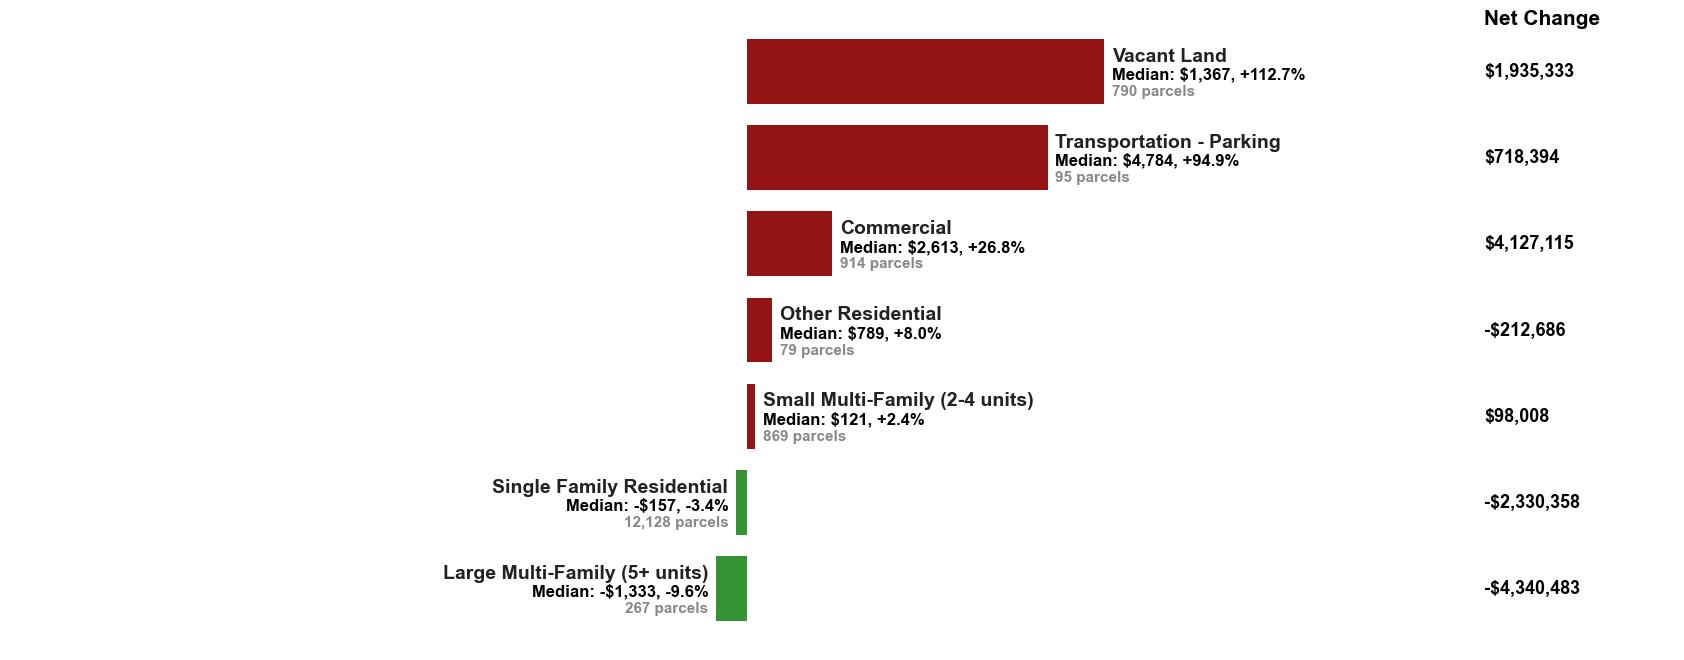

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Spokane-style property category impact chart
# Filter to categories with at least 10 parcels
filtered = category_summary[category_summary["property_count"] >= 10].copy()

categories = filtered["PROPERTY_CATEGORY"].tolist()
counts = filtered["property_count"].tolist()
median_pct_change = filtered["median_tax_change_pct"].tolist()
median_dollar_change = filtered["median_tax_change"].tolist()
total_tax_change = filtered["total_tax_change_dollars"].tolist()

# Sort ascending by median pct change
sorted_idx = np.argsort(median_pct_change)
categories = [categories[i] for i in sorted_idx]
counts = [counts[i] for i in sorted_idx]
median_pct_change = [median_pct_change[i] for i in sorted_idx]
median_dollar_change = [median_dollar_change[i] for i in sorted_idx]
total_tax_change = [total_tax_change[i] for i in sorted_idx]

bar_colors = ["#8B0000" if v > 0 else "#228B22" for v in median_pct_change]

bar_height = 0.75
fig_height = len(categories) * 0.8 + 1.2
right_col_pad = 120
fig, ax = plt.subplots(figsize=(17, fig_height))

y = np.arange(len(categories))

ax.barh(
    y, median_pct_change, color=bar_colors, edgecolor="none",
    height=bar_height, alpha=0.92, linewidth=0, zorder=2,
)

for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

cat_offset = 0.18
med_offset = -0.03
count_offset = -0.23

max_abs = max(abs(min(median_pct_change)), abs(max(median_pct_change)))
right_col_x = max_abs + right_col_pad

ax.text(
    right_col_x, len(categories) - 0.5, "Net Change", va="bottom", ha="left",
    fontsize=15, fontweight="bold", color="black", fontname="Arial",
)

for i, (cat, val, count, med_dol, tot_change) in enumerate(
    zip(categories, median_pct_change, counts, median_dollar_change, total_tax_change)
):
    med_dol_str = f"${med_dol:,.0f}" if med_dol >= 0 else f"-${abs(med_dol):,.0f}"
    pct_str = f"{val:+.1f}%"
    median_combo = f"Median: {med_dol_str}, {pct_str}"

    if val < 0:
        xpos = val - 2.5
        ha = "right"
    else:
        xpos = val + 2.5
        ha = "left"

    ax.text(xpos, y[i] + cat_offset, cat, va="center", ha=ha,
            fontsize=14, fontweight="bold", color="#222", fontname="Arial")
    ax.text(xpos, y[i] + med_offset, median_combo, va="center", ha=ha,
            fontsize=12, fontweight="bold", color="black", fontname="Arial")
    ax.text(xpos, y[i] + count_offset, f"{count:,} parcels", va="center", ha=ha,
            fontsize=11, fontweight="bold", color="#888", fontname="Arial")

    tot_str = f"${tot_change:,.0f}" if tot_change >= 0 else f"-${abs(tot_change):,.0f}"
    ax.text(right_col_x, y[i], tot_str, va="center", ha="left",
            fontsize=13, fontweight="bold", color="black", fontname="Arial")

ax.set_xlim(-right_col_x, right_col_x + 60)
ax.set_yticks([])
ax.set_xticks([])

plt.tight_layout()
plt.savefig(data_dir / "cville_4to1_category_impact.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 7: Multi-Scenario Comparison

Compare key property types across all four scenarios to understand how aggressiveness of the LVT shift affects outcomes.

In [19]:
key_cats = [
    "Single Family Residential",
    "Small Multi-Family (2-4 units)",
    "Large Multi-Family (5+ units)",
    "Commercial",
    "Vacant Land",
    "Transportation - Parking",
]

rows = []
for s in scenarios:
    summ = calculate_category_tax_summary(
        df=s["df"],
        category_col="PROPERTY_CATEGORY",
        current_tax_col="current_tax",
        new_tax_col="new_tax",
    )
    for cat in key_cats:
        row = summ[summ["PROPERTY_CATEGORY"] == cat]
        if len(row) > 0:
            rows.append({
                "Scenario": s["label"],
                "Category": cat,
                "Median % Change": row["median_tax_change_pct"].values[0],
                "n": row["property_count"].values[0],
                "Land Mill": s["land_millage"],
                "Imp Mill": s["imp_millage"],
            })

comparison = pd.DataFrame(rows)
pivot = comparison.pivot(index="Category", columns="Scenario", values="Median % Change")
print("Median city tax change (%) by scenario and property category:")
display(pivot.round(1))

Median city tax change (%) by scenario and property category:


Scenario,Full Land Tax (99:1),Split-rate 10:1,Split-rate 2:1,Split-rate 4:1
Category,,,,
Commercial,55.3,41.5,13.0,26.8
Large Multi-Family (5+ units),-19.9,-14.9,-4.7,-9.6
Single Family Residential,-7.0,-5.2,-1.6,-3.4
Small Multi-Family (2-4 units),5.0,3.7,1.2,2.4
Transportation - Parking,195.8,147.0,46.0,94.9
Vacant Land,232.6,174.6,54.6,112.7


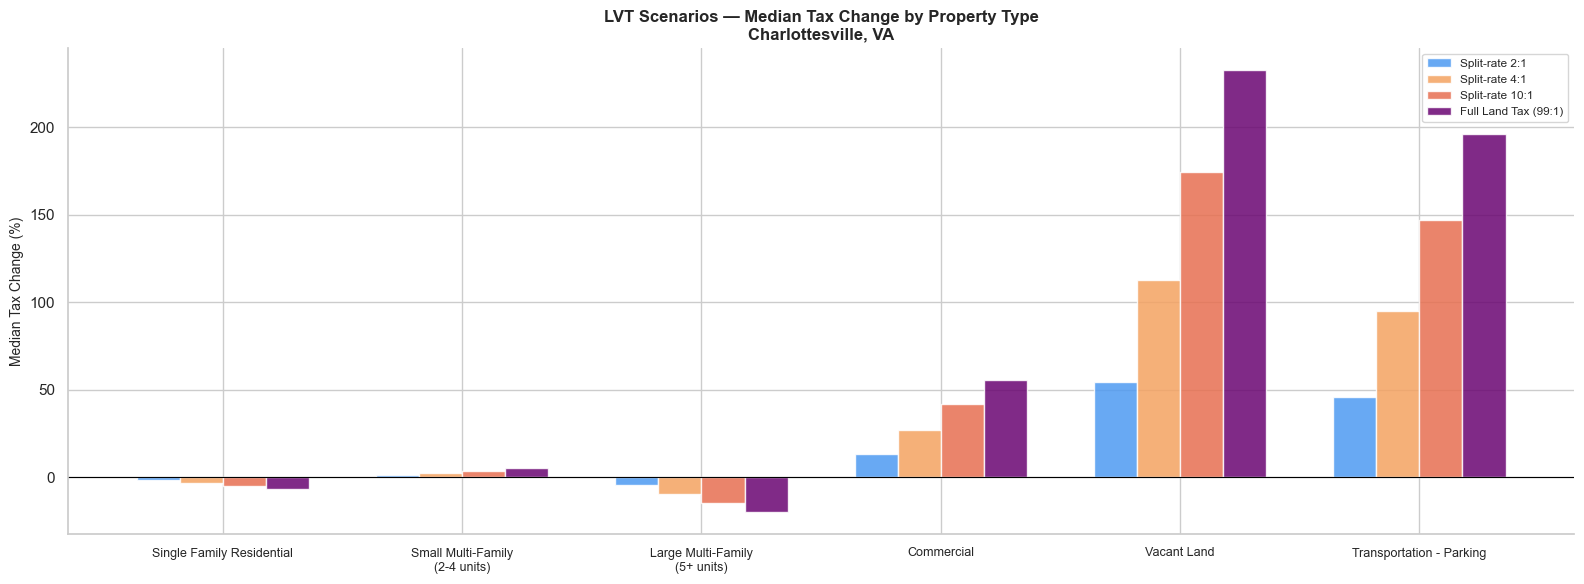

In [20]:
# Grouped bar chart: 4 scenarios × key categories
scenario_labels = [s["label"] for s in scenarios]
plot_cats = [c for c in key_cats if c in pivot.index]
x = np.arange(len(plot_cats))
width = 0.18
colors = ["#4e9af1", "#f4a261", "#e76f51", "#6a0572"]

fig, ax = plt.subplots(figsize=(16, 6))
for i, (scen, color) in enumerate(zip(scenario_labels, colors)):
    if scen in pivot.columns:
        vals = [pivot.loc[cat, scen] if cat in pivot.index else 0 for cat in plot_cats]
        bars = ax.bar(x + i * width - 1.5 * width, vals, width, label=scen,
                      color=color, alpha=0.85, edgecolor="white")

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([c.replace(" (", "\n(") for c in plot_cats], fontsize=9)
ax.set_ylabel("Median Tax Change (%)", fontsize=10)
ax.set_title(
    "LVT Scenarios — Median Tax Change by Property Type\nCharlottesville, VA",
    fontsize=12, fontweight="bold",
)
ax.legend(fontsize=8.5)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig(data_dir / "cville_scenario_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 8: Vacant Land and Parking Analysis

Charlottesville has significant infill development pressure given UVA's proximity and the city's growth constraints (surrounded by Albemarle County on all sides). Under LVT, vacant lots in desirable locations face higher carrying costs, incentivizing development or sale.

Surface parking lots in the downtown area are a particular policy focus — these are high land-value parcels with minimal improvements.

In [21]:
vacant_results = analyze_vacant_land(
    df=cville_4to1,
    land_value_col="LandValue",
    improvement_value_col="ImprovementValue",
    property_type_col="PROPERTY_CATEGORY",
    vacant_identifier="Vacant Land",
    neighborhood_col="Zone",
    exemption_flag_col="full_exmp",
)
print_vacant_land_summary(vacant_results)

VACANT LAND ANALYSIS SUMMARY
Total vacant parcels: 790
Total vacant land value: $176,069,100
Average vacant land value: $222,872
Vacant land as % of total city land value: 4.9%

Top 5 neighborhoods by vacant land value:
      count  total_value  avg_value  median_value
Zone                                             
R-A     296     40636200  137284.46      128900.0
CX-8     26     25083900  964765.38      387750.0
R-B      90     17341100  192678.89      115850.0
CX-3     57     16558100  290492.98      163400.0
CX-5     30     13585600  452853.33      206200.0


In [22]:
parking_results = analyze_parking_lots(
    df=cville_4to1,
    land_value_col="LandValue",
    improvement_value_col="ImprovementValue",
    property_type_col="PROPERTY_CATEGORY",
    parking_identifier="Transportation - Parking",
    exemption_flag_col="full_exmp",
)
print_parking_analysis_summary(parking_results)

PARKING LOT EFFICIENCY ANALYSIS
Total parking lots: 95
Total parking land value: $77,838,500
Average parking land value: $819,353
Average improvement ratio: 43.3%

Underutilized parking lots (Land value >= $50,000 and improvement ratio <= 10.0%):
Count: 46
Total land value: $43,915,700
Average land value: $954,689

Development potential:
Current improvement value: $849,800
Potential improvement value: $105,702,120
Untapped development value: $104,852,320


/Users/gregmiller/Documents/CLE/cle/LVTShift/policy_analysis.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tier_analysis = tier_df.groupby('land_value_tier').agg({


## Step 9: Improvement Ratio Distribution

The improvement ratio (IR) is the key determinant of LVT impact at the parcel level:
$$\text{IR} = \frac{\text{ImprovementValue}}{\text{TotalValue}}$$

- **High IR** (close to 1.0): well-improved property → tax goes down under LVT
- **Low IR** (close to 0.0): mostly land value → tax goes up under LVT
- **IR = 0**: vacant land → tax goes up significantly

Understanding this distribution by property type shows which neighborhoods and parcel types are most affected.

Improvement Ratio by Property Category:


,count,mean,25%,50%,75%
PROPERTY_CATEGORY,,,,,
Agricultural,8.0,0.190,0.000,0.000,0.440
Commercial,914.0,0.524,0.365,0.538,0.683
Large Multi-Family (5+ units),267.0,0.762,0.687,0.767,0.873
Other Residential,79.0,0.653,0.606,0.657,0.726
Single Family Residential,12128.0,0.715,0.666,0.728,0.779
Small Multi-Family (2-4 units),869.0,0.682,0.645,0.691,0.734
Transportation - Parking,95.0,0.201,0.012,0.112,0.376
Vacant Land,790.0,0.010,0.000,0.000,0.000


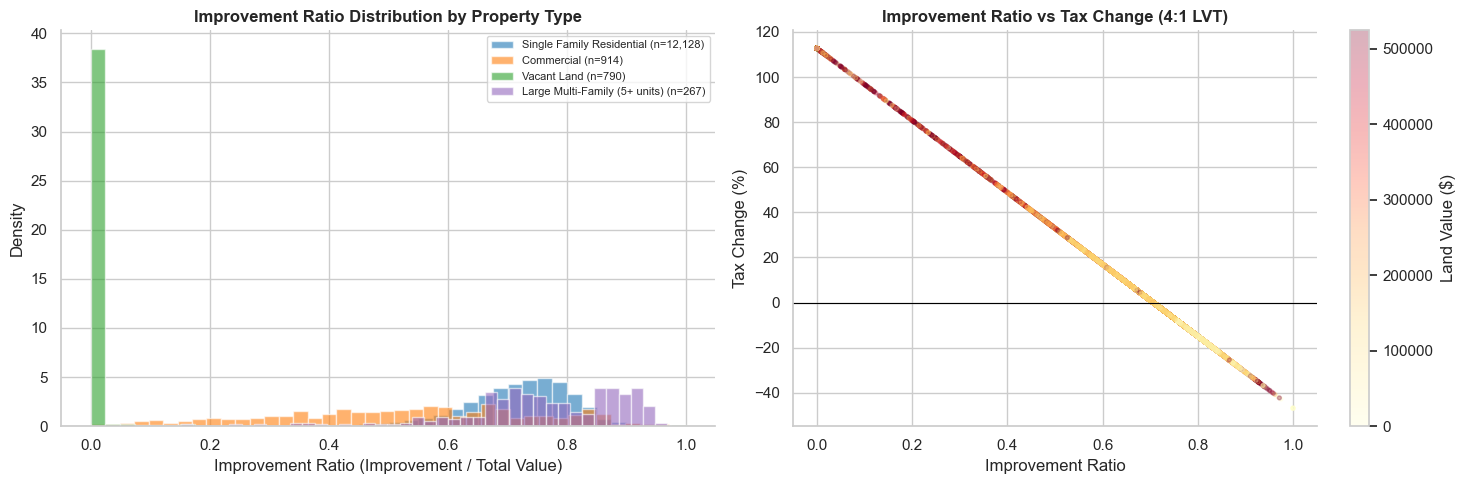

In [23]:
df_ir = cville_4to1.copy()
df_ir["IR"] = np.where(
    df_ir["TotalValue"] > 0,
    df_ir["ImprovementValue"] / df_ir["TotalValue"],
    np.nan,
)

print("Improvement Ratio by Property Category:")
ir_summary = df_ir.groupby("PROPERTY_CATEGORY")["IR"].describe().round(3)
display(ir_summary[["count", "mean", "25%", "50%", "75%"]])

# IR histogram by key categories
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

main_cats = ["Single Family Residential", "Commercial", "Vacant Land", "Large Multi-Family (5+ units)"]
cat_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#9467bd"]

for cat, color in zip(main_cats, cat_colors):
    subset = df_ir[df_ir["PROPERTY_CATEGORY"] == cat]["IR"].dropna()
    if len(subset) > 0:
        axes[0].hist(subset, bins=40, alpha=0.6, label=f"{cat} (n={len(subset):,})",
                     color=color, density=True)

axes[0].set_xlabel("Improvement Ratio (Improvement / Total Value)")
axes[0].set_ylabel("Density")
axes[0].set_title("Improvement Ratio Distribution by Property Type", fontweight="bold")
axes[0].legend(fontsize=8)
for spine in ["top", "right"]:
    axes[0].spines[spine].set_visible(False)

# Scatter: IR vs tax change %
plot_df = df_ir[(df_ir["IR"].notna()) & (df_ir["tax_change_pct"].between(-80, 300))]
sc = axes[1].scatter(
    plot_df["IR"], plot_df["tax_change_pct"],
    c=plot_df["LandValue"], cmap="YlOrRd", alpha=0.3, s=8,
    norm=plt.Normalize(0, plot_df["LandValue"].quantile(0.95)),
)
plt.colorbar(sc, ax=axes[1], label="Land Value ($)")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Improvement Ratio")
axes[1].set_ylabel("Tax Change (%)")
axes[1].set_title("Improvement Ratio vs Tax Change (4:1 LVT)", fontweight="bold")
for spine in ["top", "right"]:
    axes[1].spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig(data_dir / "cville_improvement_ratio.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 10: Census Demographics and Equity Analysis

Joining parcel-level tax changes to Census block groups allows us to test whether the LVT shift is:
- **Progressive**: lower-income and higher-minority neighborhoods see tax reductions
- **Regressive**: lower-income areas bear a higher share of the tax increase
- **Neutral**: impact is roughly uniform across demographic groups

**Census geography**: Charlottesville (FIPS 51540) is an independent city, treated as a county-equivalent. Block groups are fetched using the standard Virginia FIPS codes.

**Charlottesville context**: The city has significant income and racial segregation, with UVA's presence creating concentrations of high-income graduate students and faculty in some neighborhoods, while other areas have lower incomes and higher minority populations. This equity dimension is important for LVT policy design.

In [24]:
census_api_key = os.getenv("CENSUS_API_KEY")
print(f"CENSUS_API_KEY loaded: {bool(census_api_key)}")

census_data, census_boundaries = get_census_data_with_boundaries(
    fips_code=CHARLOTTESVILLE_FIPS,
    year=2022,
    api_key=census_api_key,
)

print(f"\nCensus block groups: {len(census_boundaries):,}")
print(f"Census data records: {len(census_data):,}")
if census_boundaries.crs is None:
    census_boundaries = census_boundaries.set_crs(epsg=4326)
print(f"CRS: {census_boundaries.crs}")
print(f"Columns: {[c for c in census_data.columns if c not in ['geometry']]}")

CENSUS_API_KEY loaded: True



Census block groups: 648
Census data records: 38
CRS: EPSG:4326
Columns: ['NAME', 'median_income', 'total_pop', 'white_pop', 'black_pop', 'hispanic_pop', 'state', 'county', 'tract', 'census_block_group', 'state_fips', 'county_fips', 'tract_fips', 'bg_fips', 'std_geoid', 'minority_pct', 'black_pct']


In [25]:
# Align CRS and spatially join parcels to census block groups
cville_for_join = cville_4to1.copy()

if cville_for_join.crs is None:
    cville_for_join = cville_for_join.set_crs(epsg=4326)
if cville_for_join.crs != census_boundaries.crs:
    cville_for_join = cville_for_join.to_crs(census_boundaries.crs)

# Filter to parcels that have geometry for the spatial join
has_geom = cville_for_join["geometry"].notna()
print(f"Parcels with geometry for spatial join: {has_geom.sum():,} of {len(cville_for_join):,}")

df_geo = match_to_census_blockgroups(
    gdf=cville_for_join[has_geom],
    census_gdf=census_boundaries,
)

print(f"Parcels matched to block groups: {len(df_geo):,}")
print(f"Unique block groups covered:     {df_geo['std_geoid'].nunique():,}")

Parcels with geometry for spatial join: 15,149 of 15,150
Parcels matched to block groups: 15,149
Unique block groups covered:     38


In [26]:
bg_summary = calculate_block_group_summary(
    df=df_geo,
    group_col="std_geoid",
    tax_change_col="tax_change",
    current_tax_col="current_tax",
    new_tax_col="new_tax",
)
print(f"Block group summary: {len(bg_summary):,} groups")
print(f"Columns: {bg_summary.columns.tolist()}")
display(bg_summary.head(5))

Block group summary: 37 groups
Columns: ['std_geoid', 'total_tax_change', 'parcel_count', 'mean_tax_change', 'mean_tax_change_pct', 'total_current_tax', 'total_new_tax', 'median_income', 'minority_pct', 'black_pct', 'total_tax_change_pct']


,std_geoid,total_tax_change,parcel_count,mean_tax_change,mean_tax_change_pct,total_current_tax,total_new_tax,median_income,minority_pct,black_pct,total_tax_change_pct
0,515400002011,-49700.034452,350,-142.000098,6.152964,2326933.56,2.277234e+06,114063.0,10.81,4.07,-2.135860
1,515400002012,279347.370382,278,1004.846656,32.760539,1492793.82,1.772141e+06,51987.0,63.01,35.19,18.713058
2,515400002013,-169811.506364,105,-1617.252442,7.530922,1729836.22,1.560025e+06,51039.0,35.29,3.83,-9.816623
3,515400002021,-894927.730033,332,-2695.565452,24.831033,5836670.28,4.941743e+06,37917.0,56.92,47.16,-15.332847
4,515400002022,-743793.341361,270,-2754.790153,-1.082800,3633161.84,2.889368e+06,18005.0,33.68,20.43,-20.472343


In [27]:
import seaborn as sns

# Cleveland-style quintile analysis on parcel-level df_geo
# df_geo has both parcel columns (tax_change, tax_change_pct, PROPERTY_CATEGORY)
# and census block group demographics (median_income, minority_pct, black_pct)

RESIDENTIAL_CATEGORIES = [
    "Single Family Residential",
    "Small Multi-Family (2-4 units)",
    "Large Multi-Family (5+ units)",
    "Other Residential",
]


def create_quintile_summary(df_input, value_col, labels=None):
    """Cleveland-style: quintiles on parcel-level data with tax_change / tax_change_pct columns."""
    if labels is None:
        labels = ["Q1 (Lowest)", "Q2", "Q3", "Q4", "Q5 (Highest)"]
    work = df_input[df_input[value_col].notna()].copy()
    if value_col == "median_income":
        work = work[work[value_col] > 0].copy()
    if len(work) < 5:
        print(f"Not enough data for quintiles on {value_col}")
        return pd.DataFrame()
    work["quintile"] = pd.qcut(work[value_col], 5, labels=labels, duplicates="drop")
    return work.groupby("quintile", observed=True).agg(
        count=("tax_change", "count"),
        mean_tax_change=("tax_change", "mean"),
        median_tax_change=("tax_change", "median"),
        mean_tax_change_pct=("tax_change_pct", "mean"),
        median_tax_change_pct=("tax_change_pct", "median"),
        mean_value=(value_col, "mean"),
    ).reset_index()


def plot_upside_down_quintile_bars(summary_df, title, save_path=None):
    """Cleveland-style inverted bar chart: bars grow downward, darker = larger tax decrease."""
    fig, ax = plt.subplots(figsize=(10, 6))

    vals = summary_df["median_tax_change_pct"].astype(float)
    labels = summary_df["quintile"]

    # Green palette: darker = more negative (larger decrease)
    colors = sns.color_palette("Greens", n_colors=len(vals))
    color_map = [colors[i] for i in np.argsort(np.argsort(-vals))]

    bars = ax.bar(
        labels,
        np.abs(vals),
        color=color_map,
        edgecolor="black",
        width=0.7,
    )

    ax.invert_yaxis()
    ax.yaxis.set_visible(False)
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.set_title(title, weight="bold", pad=30)
    sns.despine(left=True, right=True, top=True, bottom=True)

    for bar, val in zip(bars, vals):
        ax.annotate(
            f"{val:.1f}%",
            xy=(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2),
            xytext=(0, 0),
            textcoords="offset points",
            ha="center", va="center",
            fontsize=13, color="black", fontweight="bold",
        )

    ax.xaxis.set_ticks_position("top")
    ax.xaxis.set_label_position("top")
    plt.xticks(fontweight="bold")

    ymax = np.abs(vals).max() * 1.1 if len(vals) else 1
    ax.set_ylim(ymax, 0)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


# --- Filter sets ---
# 1. Excluding vacant land (all other categories)
non_vacant_geo = df_geo[df_geo["PROPERTY_CATEGORY"] != "Vacant Land"].copy()

# 2. Residential only (excl. vacant land)
residential_geo = df_geo[df_geo["PROPERTY_CATEGORY"].isin(RESIDENTIAL_CATEGORIES)].copy()

print(f"Parcel counts for demographic analysis:")
print(f"  Full modeled set (with census join): {len(df_geo):,}")
print(f"  Excl. Vacant Land:                   {len(non_vacant_geo):,}")
print(f"  Residential only:                    {len(residential_geo):,}")

Parcel counts for demographic analysis:


  Full modeled set (with census join): 15,149
  Excl. Vacant Land:                   14,359
  Residential only:                    13,342


Excl. Vacant Land — income quintile summary:


,quintile,count,mean_value,median_tax_change_pct
0,Q1 (Lowest),2887,35832.313821,-7.112684
1,Q2,2792,66421.065186,-4.460978
2,Q3,2877,80349.660758,-0.876590
3,Q4,2888,96837.268352,-1.293932
4,Q5 (Highest),2753,133677.130040,-0.448745



Excl. Vacant Land — minority quintile summary:


,quintile,count,mean_value,median_tax_change_pct
0,Q1 (Lowest),3207,9.690175,0.428441
1,Q2,2763,19.041770,-3.770492
2,Q3,2747,26.688755,-1.275125
3,Q4,3178,43.764858,-4.528910
4,Q5 (Highest),2457,60.273175,-2.969509


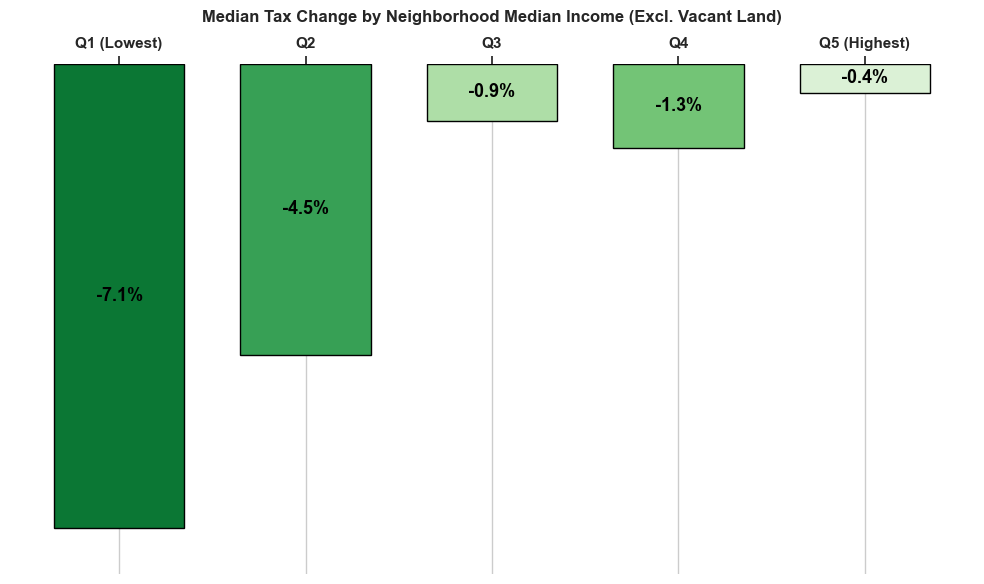

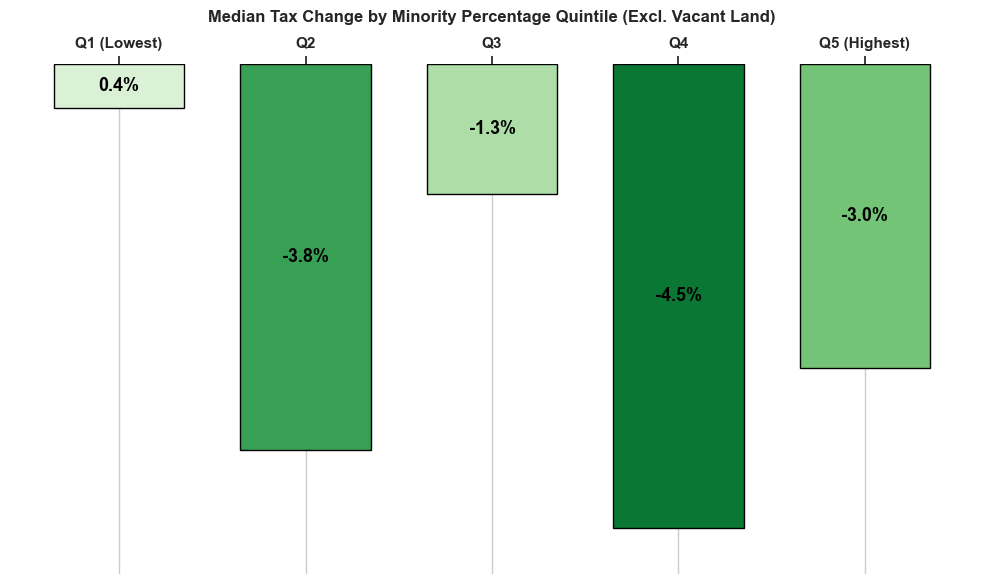


Residential Only — income quintile summary:


,quintile,count,mean_value,median_tax_change_pct
0,Q1 (Lowest),2695,35599.750278,-8.055833
1,Q2,2948,67193.096336,-5.103093
2,Q3,2336,82464.024829,-1.211910
3,Q4,2803,99244.576168,-1.063768
4,Q5 (Highest),2423,135913.200578,-1.169001



Residential Only — minority quintile summary:


,quintile,count,mean_value,median_tax_change_pct
0,Q1 (Lowest),2792,9.191712,-0.629391
1,Q2,2657,18.680745,-3.694956
2,Q3,2567,27.050136,-2.516635
3,Q4,3028,43.937414,-4.650251
4,Q5 (Highest),2291,60.558123,-4.429304


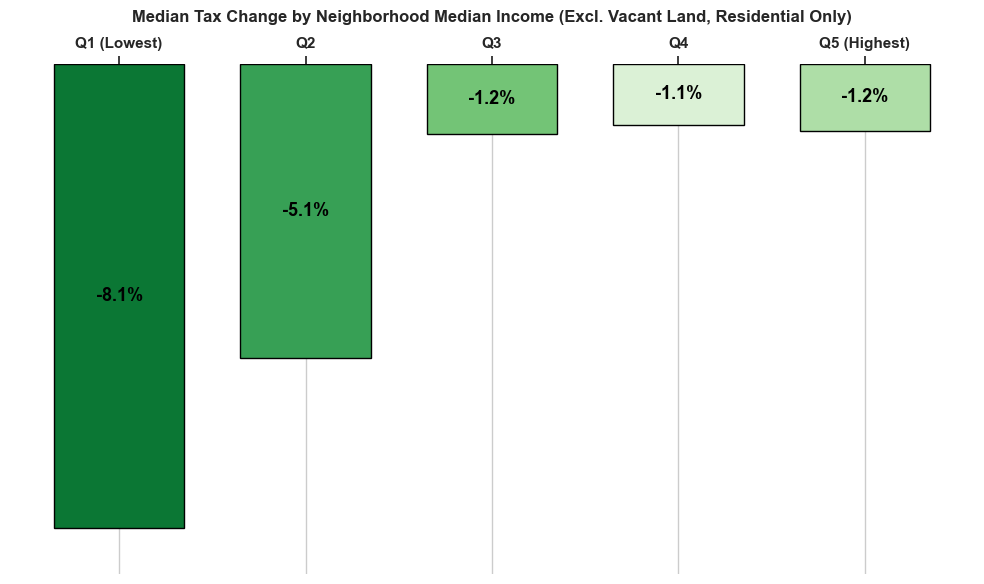

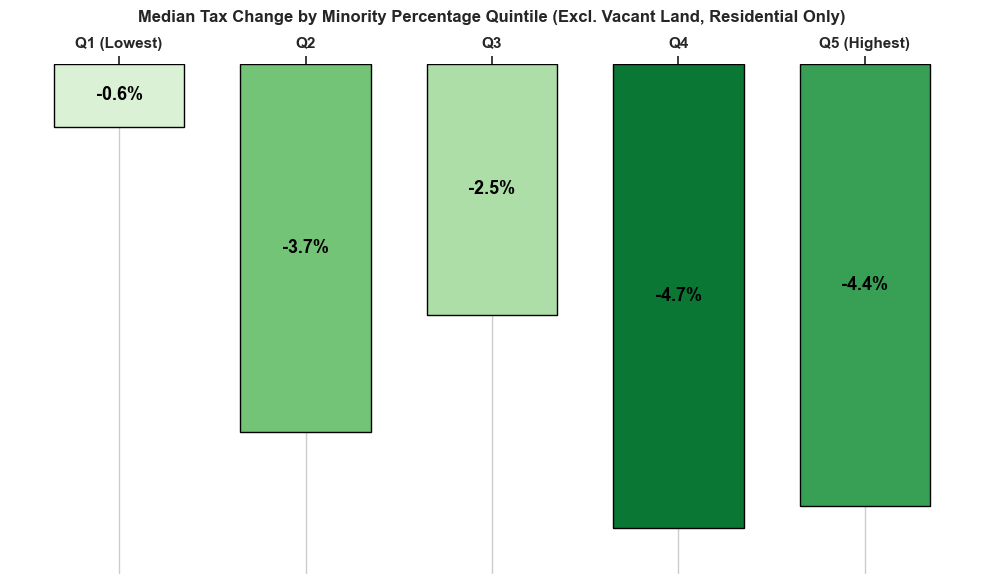

In [28]:
# --- Excl. Vacant Land: Income + Minority quintiles ---
nv_income_q = create_quintile_summary(non_vacant_geo, "median_income")
nv_minority_q = create_quintile_summary(non_vacant_geo, "minority_pct")

print("Excl. Vacant Land — income quintile summary:")
display(nv_income_q[["quintile", "count", "mean_value", "median_tax_change_pct"]])
print("\nExcl. Vacant Land — minority quintile summary:")
display(nv_minority_q[["quintile", "count", "mean_value", "median_tax_change_pct"]])

plot_upside_down_quintile_bars(
    nv_income_q,
    "Median Tax Change by Neighborhood Median Income (Excl. Vacant Land)",
    save_path=data_dir / "cville_equity_income_nonvacant.png",
)

plot_upside_down_quintile_bars(
    nv_minority_q,
    "Median Tax Change by Minority Percentage Quintile (Excl. Vacant Land)",
    save_path=data_dir / "cville_equity_minority_nonvacant.png",
)

# --- Residential only: Income + Minority quintiles ---
res_income_q = create_quintile_summary(residential_geo, "median_income")
res_minority_q = create_quintile_summary(residential_geo, "minority_pct")

print("\nResidential Only — income quintile summary:")
display(res_income_q[["quintile", "count", "mean_value", "median_tax_change_pct"]])
print("\nResidential Only — minority quintile summary:")
display(res_minority_q[["quintile", "count", "mean_value", "median_tax_change_pct"]])

plot_upside_down_quintile_bars(
    res_income_q,
    "Median Tax Change by Neighborhood Median Income (Excl. Vacant Land, Residential Only)",
    save_path=data_dir / "cville_equity_income_residential.png",
)

plot_upside_down_quintile_bars(
    res_minority_q,
    "Median Tax Change by Minority Percentage Quintile (Excl. Vacant Land, Residential Only)",
    save_path=data_dir / "cville_equity_minority_residential.png",
)

## Step 11: Land Value Distribution Map

Visualize the geographic distribution of land values and LVT tax changes across Charlottesville. This helps identify where the policy has the most significant effects spatially.

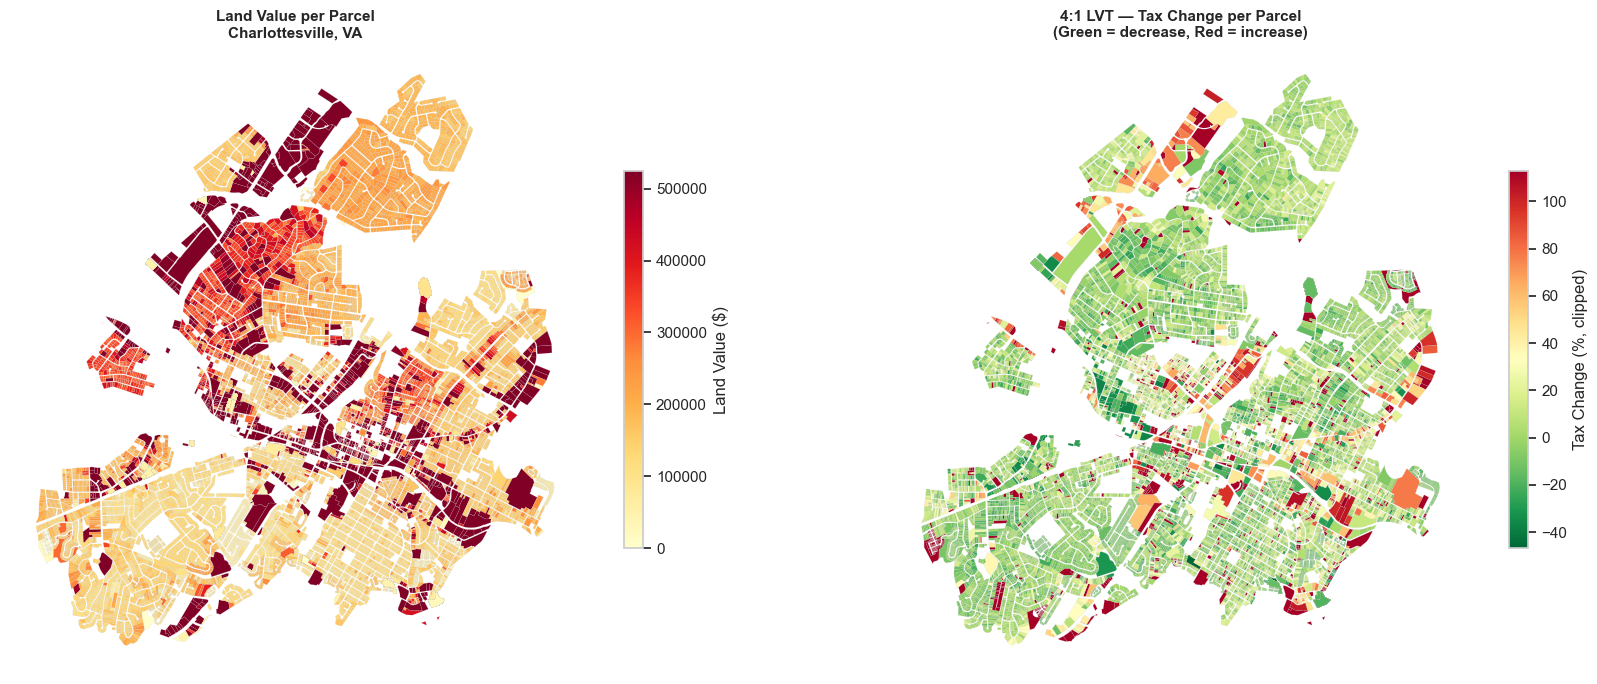

Map saved: /Users/gregmiller/Documents/CLE/cle/LVTShift/examples/data/charlottesville/cville_land_value_map.png


In [29]:
# Map parcels with geometry, colored by land value
map_df = cville_4to1[cville_4to1["geometry"].notna()].copy()

if len(map_df) == 0:
    print("No geometry available for mapping — skipping spatial visualization")
else:
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # Cap values at 95th percentile for color scale
    land_cap = map_df["LandValue"].quantile(0.95)
    change_pct_clip = map_df["tax_change_pct"].clip(-60, 200)

    map_df.plot(
        column="LandValue",
        ax=axes[0],
        cmap="YlOrRd",
        legend=True,
        legend_kwds={"label": "Land Value ($)", "shrink": 0.6},
        vmin=0, vmax=land_cap,
        linewidth=0.1, edgecolor="#cccccc",
    )
    axes[0].set_title("Land Value per Parcel\nCharlottesville, VA", fontsize=11, fontweight="bold")
    axes[0].set_axis_off()

    map_df.assign(tax_change_pct_clip=change_pct_clip).plot(
        column="tax_change_pct_clip",
        ax=axes[1],
        cmap="RdYlGn_r",
        legend=True,
        legend_kwds={"label": "Tax Change (%, clipped)", "shrink": 0.6},
        linewidth=0.1, edgecolor="#cccccc",
    )
    axes[1].set_title(
        "4:1 LVT — Tax Change per Parcel\n(Green = decrease, Red = increase)",
        fontsize=11, fontweight="bold",
    )
    axes[1].set_axis_off()

    plt.tight_layout()
    plt.savefig(data_dir / "cville_land_value_map.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Map saved: {data_dir / 'cville_land_value_map.png'}")

## Step 12: Summary and Policy Implications

### What LVT Means for Charlottesville

Charlottesville's position as a university city with constrained land supply (surrounded by Albemarle County on all sides) makes it an interesting LVT case study:

1. **Development pressure**: With limited land area and UVA expansion, vacant and underutilized parcels near the downtown core carry significant opportunity cost. LVT increases the carrying cost of holding land without improvement, incentivizing development.

2. **Affordable housing**: The city has faced significant housing cost increases. LVT can shift the tax burden toward land (rather than buildings), which:
   - Reduces the cost of building and owning dense housing
   - Captures land value increases driven by public investment and UVA's presence
   - Discourages speculative land holding that limits housing supply

3. **UVA's exempt land**: A significant portion of Charlottesville's highest-value land is owned by UVA and therefore exempt. This limits the taxable land base but also means any LVT reform primarily affects private landowners and commercial parking operators.

4. **Virginia authority**: Virginia's Constitution (Article X) and enabling statutes currently require uniform property tax rates. A split-rate LVT in Virginia would require either a constitutional amendment or specific state enabling legislation (similar to Pennsylvania's approach).

In [30]:
s2 = next(s for s in scenarios if s["ratio"] == 2.0)
s4 = next(s for s in scenarios if s["ratio"] == 4.0)
s10 = next(s for s in scenarios if s["ratio"] == 10.0)

print("=" * 70)
print("CHARLOTTESVILLE, VA — LVT MODEL SUMMARY (2025 Full City Levy)")
print("=" * 70)
print(f"Current flat millage:          {CITY_MILLAGE} mills (${CITY_MILLAGE/10:.2f}/$100)")
print(f"Current modeled revenue:       ${current_revenue:,.0f}")
print(f"Taxable parcels modeled:       {len(df):,}")
print(f"Total taxable assessed value:  ${df['TotalValue'].sum():,.0f}")
print()

total_land = df["LandValue"].sum()
total_imp = df["ImprovementValue"].sum()
total_val = df["TotalValue"].sum()
print(f"Taxable land value:            ${total_land:,.0f} ({total_land/total_val*100:.1f}% of total)")
print(f"Taxable improvement value:     ${total_imp:,.0f} ({total_imp/total_val*100:.1f}% of total)")
print()

print("Scenario Results:")
print(f"  {'Scenario':<28} {'Land Mill':>10} {'Imp Mill':>10} {'Med SF %':>10}")
print(f"  {'-'*62}")
for s in scenarios:
    print(f"  {s['label']:<28} {s['land_millage']:>10.4f} {s['imp_millage']:>10.4f} {s['median_sf_pct']:>9.1f}%")

print()
print("Data Sources:")
print("  Assessment tables: Charlottesville GIS OpenData_2 MapServer")
print("  Geometry:          Charlottesville GIS OpenData_1 MapServer (Layer 43)")
print("  Tax rate:          City Council adopted rate, FY2025 ($0.98/$100)")
print("  Census:            ACS 2022 5-year estimates (FIPS 51540)")
print()
print("Virginia LVT Note: A split-rate property tax in Virginia currently requires")
print("state enabling legislation. Virginia's uniformity clause (Art. X, Sec. 1)")
print("mandates uniform rates — Pennsylvania's enabling statute is a useful model.")

CHARLOTTESVILLE, VA — LVT MODEL SUMMARY (2025 Full City Levy)
Current flat millage:          9.8 mills ($0.98/$100)
Current modeled revenue:       $119,456,768
Taxable parcels modeled:       15,150
Total taxable assessed value:  $12,189,466,100

Taxable land value:            $3,577,842,100 (29.4% of total)
Taxable improvement value:     $8,611,624,000 (70.6% of total)

Scenario Results:
  Scenario                      Land Mill   Imp Mill   Med SF %
  --------------------------------------------------------------
  Split-rate 2:1                  15.1525     7.5762      -1.6%
  Split-rate 4:1                  20.8449     5.2112      -3.4%
  Split-rate 10:1                 26.9107     2.6911      -5.2%
  Full Land Tax (99:1)            32.5955     0.3292      -7.0%

Data Sources:
  Assessment tables: Charlottesville GIS OpenData_2 MapServer
  Geometry:          Charlottesville GIS OpenData_1 MapServer (Layer 43)
  Tax rate:          City Council adopted rate, FY2025 ($0.98/$100)
  Cens

In [31]:
# Save final modeled dataset for further analysis
output_path = data_dir / "cville_4to1_modeled.parquet"
save_cols = [
    "PN", "ParcelNumber", "GPIN", "TaxType", "StateCode", "Zone", "Acreage",
    "UseCode", "YearBuilt", "PROPERTY_CATEGORY",
    "LandValue", "ImprovementValue", "TotalValue",
    "current_tax", "new_tax", "tax_change", "tax_change_pct",
    "full_exmp",
]
available_cols = [c for c in save_cols if c in cville_4to1.columns]

# Drop geometry for plain parquet
cville_4to1[available_cols].to_parquet(output_path, index=False)
print(f"Modeled data saved: {output_path}")
print(f"Columns saved:      {available_cols}")
print(f"Row count:          {len(cville_4to1):,}")

Modeled data saved: /Users/gregmiller/Documents/CLE/cle/LVTShift/examples/data/charlottesville/cville_4to1_modeled.parquet
Columns saved:      ['PN', 'ParcelNumber', 'GPIN', 'TaxType', 'StateCode', 'Zone', 'Acreage', 'UseCode', 'YearBuilt', 'PROPERTY_CATEGORY', 'LandValue', 'ImprovementValue', 'TotalValue', 'current_tax', 'new_tax', 'tax_change', 'tax_change_pct', 'full_exmp']
Row count:          15,150
